In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [3]:
A = np.array([[2,3],
             [3,3],
             [2,2]])

B = np.array([[7,8],
             [8,8],
             [9,9]])

In [4]:
mu_A = np.mean(A, axis = 0)
mu_B = np.mean(B, axis = 0)

In [8]:
def scatter_matrix(X, mu):
    S = np.zeros((2,2))
    for x in X:
        x = x.reshape(2,1)
        mu_vec = mu.reshape(2,1)
        S += (x - mu_vec) @ (x - mu_vec).T
    return S

In [9]:
S_A = scatter_matrix(A, mu_A)
S_B_within = scatter_matrix(B, mu_B)
S_W = S_A + S_B_within

In [10]:
# Step 4: Between Class Scatter SB
mean_diff = (mu_A - mu_B).reshape(2,1)
S_B = mean_diff @ mean_diff.T

In [11]:
# Step 5: Compute projection vector w
w = np.linalg.inv(S_W) @ (mu_B - mu_A)

# normalize for visualization
w_norm = w / np.linalg.norm(w)

In [12]:
# step 6: Project Points
proj_A = A @ w
proj_B = B @ w

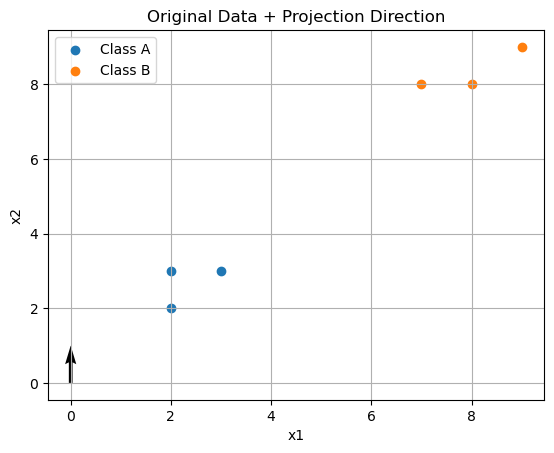

In [14]:
# visualization

# 1Plot original 2D data
plt.figure()

plt.scatter(A[:, 0], A[:,1], label="Class A")
plt.scatter(B[:, 0], B[:,1], label="Class B")

# Plot projection direction line
origin = np.array([0,0])
plt.quiver(*origin, *w_norm, angles='xy', scale_units='xy', scale=1)
plt.title("Original Data + Projection Direction")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid()

plt.show()

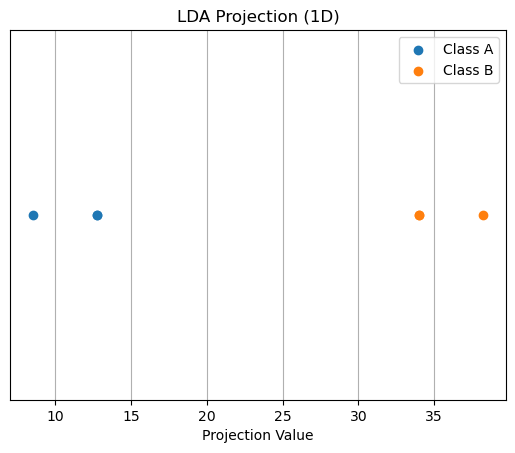

In [15]:
# Plot 1D Projection
plt.figure()

plt.scatter(proj_A, np.zeros_like(proj_A), label="Class A")
plt.scatter(proj_B, np.zeros_like(proj_B), label="Class B")
# Plot projection direction line
plt.title("LDA Projection (1D)")
plt.xlabel("Projection Value")
plt.yticks([])
plt.legend()
plt.grid()

plt.show()
